# Predict the electricity price

* Features:
    - electricy demand prediction
    - PV generation prediction
    - wind generation prediction
    - residual load (PV generation + wind generation - electricity demand)
*

In [26]:
# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})

import sys
import os

# Add the src directory to the system path to allow importing custom modules
project_root = os.path.abspath("..")
src_dir = os.path.join(project_root, "src")
util_dir = os.path.join(project_root, "util")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)
if util_dir not in sys.path:
    sys.path.insert(0, util_dir)


import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2
    
from src.config import *
from util.weather_weighted import *
from src.etl_price import *
from src.fetch_price_data import *
from src.train_predict_model import *
from util.time_features import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import numpy as np
import pandas as pd
from pathlib import Path

update_database()

# One-liner data preparation: loads, merges, engineers features, returns training-ready dataset 
df_price_model = prepare_price_model_dataset()

print("model rows:", len(df_price_model))
print("time range:", df_price_model["time"].min(), "->", df_price_model["time"].max())
print("feature count:", len(df_price_model.columns) - 2)  # Subtracting 'time' and target column
display(df_price_model.shape)

Series catalog seeded/updated rows: 14

Current SMARD data status:
  price_de_lu_eur_mwh         :  65135 rows | max: 2026-06-06T21:00:00Z
  gen_wind_onshore_mwh        :  65103 rows | max: 2026-06-05T13:00:00Z
  gen_wind_offshore_mwh       :  65104 rows | max: 2026-06-05T14:00:00Z
  gen_pv_mwh                  :  65104 rows | max: 2026-06-05T14:00:00Z
  gen_other_conventional_mwh  :  65104 rows | max: 2026-06-05T14:00:00Z
  forecast_wind_onshore_mwh   :  65111 rows | max: 2026-06-05T21:00:00Z
  forecast_wind_offshore_mwh  :  65111 rows | max: 2026-06-05T21:00:00Z
  forecast_pv_mwh             :  65111 rows | max: 2026-06-05T21:00:00Z

Fetching and storing SMARD price/generation series: 2026-06-05 → 2026-06-06
Batch ingestion result: {'run_id': 26, 'status': 'success', 'total_inserted': 73, 'per_series': {'price_de_lu_eur_mwh': 0, 'gen_wind_onshore_mwh': 0, 'gen_wind_offshore_mwh': 0, 'gen_pv_mwh': 0, 'gen_other_conventional_mwh': 1, 'forecast_wind_onshore_mwh': 24, 'forecast_wind_offs

(64552, 49)

In [28]:
# Train-test split by date
split_date = pd.Timestamp("2025-10-01", tz="UTC")
price_features_train, price_target_train, price_features_test, price_target_test = train_test_split_by_date(
    df = df_price_model, date_column='time', target_column="price_de_lu_eur_mwh", split_date=split_date
)
print("Training set:", price_features_train.shape, price_target_train.shape)
print("Testing set:", price_features_test.shape, price_target_test.shape)

Training set: (58818, 47) (58818,)
Testing set: (5734, 47) (5734,)


In [ ]:
# predict price for tomorrow
import datetime

df_tomorrow = prepare_data_for_price_prediction_tomorrow()


Predicted price for tomorrow (LightGBM) EUR/MWh: 
[111.65196724  51.94503544 109.27481694  51.58053274 113.36400813
  45.37440321  56.40189713  50.19819942  36.49534989  50.56523654
  30.12042497  22.52580313  63.50559613 -16.10812963  20.66500958
 -11.35173684  29.06650338   3.80048556   4.99221287 122.96084319
 100.77483879  79.49730433  75.63100494  62.95258046] 
Predicted price for tomorrow (XGBoost) EUR/MWh: 
[  45.928543  630.20886    43.714367  663.54       49.54523   645.6329
  568.32886   542.28033   537.82214   520.0457    535.11816   517.6795
  -47.715694 -111.77235   551.4484    -94.306274  -36.137665  169.59743
  196.18515   -46.397003  703.4629    721.7887    692.0751    598.62164 ] 
prices of yesterday:
 [134.79, 127.52, 120.54, 118.87, 119.05, 121.24, 134.2, 131.1, 106.45, 48.24, 3.43, -0.27, -1.05, -1.64, -1.65, -1.7, -0.42, 32.21, 97.85, 136.52, 156.68, 157.53, 144.16, 133.45]
prices of last 7 days:
 [132.38875, 127.76083333333334, 122.75291666666668, 136.418750000000

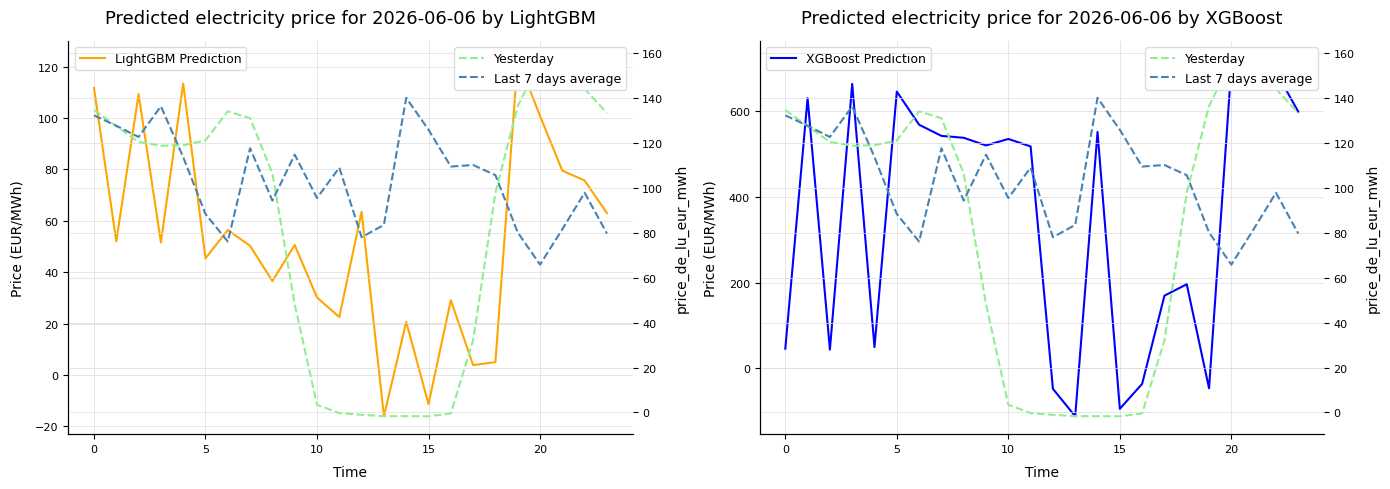

In [51]:
# plot predition for tomorrow and compare with historical price distribution
price_model_lgbm = load_model_from_pickle('../models/price_lgbm_model.pkl')
price_model_xgb = load_model_from_pickle('../models/price_xgb_model.pkl')
price_features_train = price_model_lgbm.feature_name_

pred_price_lgbm = price_model_lgbm.predict(df_tomorrow[price_features_train])
pred_price_xgb = price_model_xgb.predict(df_tomorrow[price_features_train]) 
print(f"Predicted price for tomorrow (LightGBM) EUR/MWh: \n{pred_price_lgbm} ")
print(f"Predicted price for tomorrow (XGBoost) EUR/MWh: \n{pred_price_xgb} ")

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

tomorrow = (pd.Timestamp.now(tz='UTC').normalize() + pd.Timedelta(days=1)).date()
yesterday = (pd.Timestamp.now(tz='UTC').normalize() - pd.Timedelta(days=1)).date()
# time series of today and tomorrow
#time_range = pd.date_range(start=tomorrow , freq='h', periods=24, tz='UTC')
time_range = range(24)

df_price_yesterday = df_price_model['price_de_lu_eur_mwh'].tail(24)
df_price_last7days = df_price_model.resample('D', on='time')['price_de_lu_eur_mwh'].mean().tail(24).reset_index(drop=True)

print('prices of yesterday:\n', df_price_yesterday.to_list())
print('prices of last 7 days:\n', df_price_last7days.to_list())

plt.figure(figsize=(14, 5))
ax1 = plt.subplot(1, 2, 1)
sns.lineplot(x=time_range, y=pred_price_lgbm, color='orange', ax=ax1)
ax1.set_title(f'Predicted electricity price for {tomorrow} by LightGBM')
ax1.set_xlabel('Time')
ax1.set_ylabel('Price (EUR/MWh)')
ax1.legend(['LightGBM Prediction'], loc='upper left')
ax1_twinx = ax1.twinx()
sns.lineplot(x=time_range, y=df_price_yesterday, color='lightgreen', linestyle='--', ax=ax1_twinx, label='Yesterday')
sns.lineplot(x=time_range, y=df_price_last7days, color='steelblue', linestyle='--', ax=ax1_twinx, label='Last 7 days average')
ax1_twinx.legend(loc='upper right')

ax2 = plt.subplot(1, 2, 2)
sns.lineplot(x=time_range, y=pred_price_xgb, color='blue', ax=ax2)
ax2.set_title(f'Predicted electricity price for {tomorrow} by XGBoost')
ax2.set_xlabel('Time')
ax2.set_ylabel('Price (EUR/MWh)')
ax2.legend(['XGBoost Prediction'], loc='upper left')
ax2_twinx = ax2.twinx()
sns.lineplot(x=time_range, y=df_price_yesterday, color='lightgreen', linestyle='--', ax=ax2_twinx, label='Yesterday')
sns.lineplot(x=time_range, y=df_price_last7days, color='steelblue', linestyle='--', ax=ax2_twinx, label='Last 7 days average')
ax2_twinx.legend(loc='upper right')

plt.tight_layout()
plt.show()